In [2]:
#!/usr/bin/env python3
"""
DREAM Night Cloud Classification & ML Clustering
=================================================
Classifies every night in the DREAM history as:
  - CLEAR          : sky mostly transparent (valid_frac < 0.10)
  - FULLY CLOUDY   : sky mostly blocked     (valid_frac > 0.90)
  - PARTIALLY CLOUDY: patchy clouds          (0.10 ≤ valid_frac ≤ 0.90,
                                              spatial_var > VAR_THRESH)
  - UNIFORM THIN   : thin uniform cloud     (0.10 ≤ valid_frac ≤ 0.90,
                                              spatial_var ≤ VAR_THRESH)

Then runs K-means clustering on the partially-cloudy nights to find
sub-types, prints representative examples, and produces:
  1. all_nights_classification.csv
  2. cloud_classification_overview.png   (pie + bar + timeline)
  3. partial_cloud_clusters.png          (cluster scatter + monthly dist)

Usage:
    python dream_cloud_classification.py \
        --csv feb5_data.csv \
        --n-probe 10 \
        --n-clusters 3 \
        --output-dir .

CONFIG at the top of the file can override all defaults.
"""

import io
import os
import re
import sys
import warnings
import numpy as np
import pandas as pd
import h5py
import healpy as hp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.ndimage import gaussian_filter
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u
from lsst.resources import ResourcePath

warnings.filterwarnings("ignore")

os.environ.setdefault("no_proxy", "")
if ".consdb" not in os.environ["no_proxy"]:
    os.environ["no_proxy"] += ",.consdb"

# ═══════════════════════════════════════════════════════════════
# CONFIG  — edit or override with CLI args
# ═══════════════════════════════════════════════════════════════
CSV_FILE    = "feb5_data.csv"
OUTPUT_DIR  = "."
N_PROBE     = 10       # frames sampled per night for quick check
N_CLUSTERS  = 3        # k-means clusters on partially-cloudy nights
              # set to 0 → auto-detect via elbow / silhouette (k=2..6)
N_EXAMPLES  = 3        # example nights printed per category / cluster
RANDOM_SEED = 42

# Thresholds
CLEAR_FRAC_MAX  = 0.10   # valid_frac below this → CLEAR
CLOUD_FRAC_MIN  = 0.90   # valid_frac above this → FULLY CLOUDY
VAR_THRESH      = 0.05   # mag²  spatial variance boundary (patchy vs uniform)

# HDF5 quality
MAX_SIGMA_MAG  = 0.3
MAX_FLAG_VALUE = 0
MIN_ALT_DEG    = 15.0
NSIDE          = 32
NEST           = True

BIN_SIZE_KM    = 1000
R_PROJ         = 10000.0  # km

URL_COL  = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL = "time"

RUBIN_LAT      = -30.244639
RUBIN_LON      = -70.749417
RUBIN_HEIGHT_M = 2663.0

CATEGORY_COLORS = {
    "CLEAR":            "#2CA02C",   # green
    "PARTIALLY CLOUDY": "#FF7F0E",   # orange
    "UNIFORM THIN":     "#1F77B4",   # blue
    "FULLY CLOUDY":     "#D62728",   # red
}

CLUSTER_COLORS = ["#7B2FBE", "#E377C2", "#8C564B", "#17BECF", "#BCBD22"]

# ═══════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════

def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url


def _make_location():
    return EarthLocation(lat=RUBIN_LAT*u.deg,
                         lon=RUBIN_LON*u.deg,
                         height=RUBIN_HEIGHT_M*u.m)


def _ensure_time(t):
    if not isinstance(t, Time):
        t = Time(t)
    return t.utc


def fetch_sys_map(url):
    """Load cloud_sys HDF5 → (clouds, sigma) arrays with bad pixels = NaN."""
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    with h5py.File(io.BytesIO(data), "r") as f:
        clouds       = np.array(f["clouds"],       dtype=float).ravel()
        sigma        = np.array(f["sigma"],        dtype=float).ravel()
        flags        = np.array(f["flags"],        dtype=int  ).ravel()
        mask_visible = np.array(f["mask_visible"], dtype=bool ).ravel()
        nobs         = np.array(f["nobs"],         dtype=int  ).ravel()
    bad = (
        ~mask_visible | (nobs == 0) | (flags > MAX_FLAG_VALUE)
        | (sigma > MAX_SIGMA_MAG) | ~np.isfinite(clouds)
    )
    clouds[bad] = np.nan
    sigma [bad] = np.nan
    return clouds, sigma


def healpix_to_grid(hp_map, obstime, bin_km=BIN_SIZE_KM):
    """Project HEALPix map onto flat-sky km grid, returns 2-D array."""
    npix = hp.nside2npix(NSIDE)
    pix  = np.arange(npix)
    th, ph = hp.pix2ang(NSIDE, pix, nest=NEST)
    ra  = np.degrees(ph)
    dec = 90.0 - np.degrees(th)
    t   = _ensure_time(obstime)
    loc = _make_location()
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=loc))

    alt  = aa.alt.deg
    az   = np.radians(aa.az.deg % 360)
    altr = np.radians(alt)
    above = alt > MIN_ALT_DEG
    scale = np.where(above, R_PROJ / np.sin(altr), np.nan)
    xf = -np.cos(altr) * np.sin(az) * scale
    yf =  np.cos(altr) * np.cos(az) * scale
    vf = np.where(above, np.asarray(hp_map, float), np.nan)

    x_edges = np.arange(-15000, 15001, bin_km)
    y_edges = np.arange(-15000, 15001, bin_km)
    ok = ~np.isnan(xf) & ~np.isnan(yf) & ~np.isnan(vf)
    Hs, _, _ = np.histogram2d(xf[ok], yf[ok], bins=[x_edges, y_edges], weights=vf[ok])
    Hc, _, _ = np.histogram2d(xf[ok], yf[ok], bins=[x_edges, y_edges])
    with np.errstate(divide="ignore", invalid="ignore"):
        H = Hs / Hc
    H[Hc == 0] = np.nan
    H = H.T
    xc = (x_edges[:-1] + x_edges[1:]) / 2
    yc = (y_edges[:-1] + y_edges[1:]) / 2
    Xg, Yg = np.meshgrid(xc, yc)
    H[np.sqrt(Xg**2 + Yg**2) > 15000] = np.nan
    return H


# ═══════════════════════════════════════════════════════════════
# CSV loading
# ═══════════════════════════════════════════════════════════════

def load_sys_index(csv_file):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.replace('"', "").str.strip()
    df = df.dropna(subset=[URL_COL]).copy()
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce", utc=True)
    df = df.dropna(subset=[TIME_COL]).copy()
    df = df[df[URL_COL].str.contains(r"\.hdf5",    case=False, na=False, regex=True)]
    df = df[df[URL_COL].str.contains("cloud_sys",  case=False, na=False)].copy()
    df = df.sort_values(TIME_COL).reset_index(drop=True)
    shifted = df[TIME_COL] - pd.Timedelta(hours=12)
    df["night_key"] = shifted.dt.date
    return df


# ═══════════════════════════════════════════════════════════════
# Per-night metrics (probe N evenly-spaced frames)
# ═══════════════════════════════════════════════════════════════

def night_metrics(df_night, n_probe=N_PROBE):
    """
    Sample n_probe frames from a night.
    Returns dict with:
      valid_frac_mean, valid_frac_std,
      spatial_var_mean, spatial_var_std,
      mean_extinction, mean_sigma,
      n_frames_probed, n_frames_total,
      timestamps (list), grids (list)
    """
    n_total = len(df_night)
    idx = np.linspace(0, n_total - 1, min(n_probe, n_total), dtype=int)
    fracs, vars_, exts, sigs = [], [], [], []
    grids, times = [], []

    for i in idx:
        row = df_night.iloc[i]
        url = transform_url(row[URL_COL])
        try:
            clouds, sigma = fetch_sys_map(url)
            t = row[TIME_COL].to_pydatetime()
            g = healpix_to_grid(clouds, t)
            fracs.append(np.sum(~np.isnan(g)) / g.size)
            vars_.append(float(np.nanvar(g)) if np.sum(~np.isnan(g)) > 10 else 0.0)
            exts.append(float(np.nanmean(clouds[~np.isnan(clouds)])) if np.any(~np.isnan(clouds)) else np.nan)
            sigs.append(float(np.nanmean(sigma[~np.isnan(sigma)])) if np.any(~np.isnan(sigma)) else np.nan)
            grids.append(g)
            times.append(t)
        except Exception as e:
            pass   # frame load failure → skip

    if not fracs:
        return None

    return {
        "valid_frac_mean":  float(np.mean(fracs)),
        "valid_frac_std":   float(np.std(fracs)),
        "spatial_var_mean": float(np.mean(vars_)),
        "spatial_var_std":  float(np.std(vars_)),
        "mean_extinction":  float(np.nanmean(exts)) if exts else np.nan,
        "mean_sigma":       float(np.nanmean(sigs)) if sigs else np.nan,
        "n_frames_probed":  len(fracs),
        "n_frames_total":   n_total,
        "timestamps":       times,
        "grids":            grids,
    }


# ═══════════════════════════════════════════════════════════════
# Classification
# ═══════════════════════════════════════════════════════════════

def classify_night(m):
    """
    Returns one of: CLEAR | FULLY CLOUDY | PARTIALLY CLOUDY | UNIFORM THIN
    
    Metrics used
    ────────────
    valid_frac_mean : fraction of sky pixels with valid (non-NaN) extinction
        Low  → sensor/HEALPix has good coverage → clear sky (few clouds blocking)
        High → most pixels masked/bad → heavy cloud cover
    
    spatial_var_mean : mean within-frame spatial variance of extinction (mag²)
        Low  → extinction is spatially uniform (either clear OR uniformly overcast)
        High → extinction varies across the sky → patchy/broken clouds
    
    Decision tree:
        valid_frac < CLEAR_FRAC_MAX              → CLEAR
        valid_frac > CLOUD_FRAC_MIN              → FULLY CLOUDY
        CLEAR_FRAC_MAX ≤ valid_frac ≤ CLOUD_FRAC_MIN:
            spatial_var > VAR_THRESH             → PARTIALLY CLOUDY
            spatial_var ≤ VAR_THRESH             → UNIFORM THIN (thin uniform veil)
    """
    frac = m["valid_frac_mean"]
    var  = m["spatial_var_mean"]

    if frac < CLEAR_FRAC_MAX:
        return "CLEAR"
    if frac > CLOUD_FRAC_MIN:
        return "FULLY CLOUDY"
    if var > VAR_THRESH:
        return "PARTIALLY CLOUDY"
    return "UNIFORM THIN"


def category_description(cat):
    descs = {
        "CLEAR": (
            f"valid_frac < {CLEAR_FRAC_MAX:.2f}: very few HEALPix pixels are masked, "
            "meaning the sky is largely transparent. Extinction values are low and "
            "spatially smooth. Ideal for science."
        ),
        "FULLY CLOUDY": (
            f"valid_frac > {CLOUD_FRAC_MIN:.2f}: nearly all sky pixels are masked/bad, "
            "indicating heavy cloud cover that blocks most of the sky. "
            "Not usable for science."
        ),
        "PARTIALLY CLOUDY": (
            f"{CLEAR_FRAC_MAX:.2f} ≤ valid_frac ≤ {CLOUD_FRAC_MIN:.2f} AND "
            f"spatial_var > {VAR_THRESH:.3f} mag²: "
            "a substantial fraction of the sky is cloud-affected, but clouds are "
            "spatially heterogeneous (patchy). Some fields may still be observable. "
            "Cloud-motion tracking can help exploit clear windows."
        ),
        "UNIFORM THIN": (
            f"{CLEAR_FRAC_MAX:.2f} ≤ valid_frac ≤ {CLOUD_FRAC_MIN:.2f} AND "
            f"spatial_var ≤ {VAR_THRESH:.3f} mag²: "
            "thin but spatially uniform cloud veil. Extinction is present across "
            "most of the sky but relatively constant — no patchy structure. "
            "May still yield photometry with a global zero-point offset."
        ),
    }
    return descs.get(cat, "")


# ═══════════════════════════════════════════════════════════════
# K-means clustering on partially-cloudy nights
# ═══════════════════════════════════════════════════════════════

FEATURE_COLS = [
    "valid_frac_mean", "valid_frac_std",
    "spatial_var_mean", "spatial_var_std",
    "mean_extinction",
]

def auto_k(X_scaled, k_range=range(2, 7), seed=RANDOM_SEED):
    """Pick k using silhouette score."""
    best_k, best_score = 2, -1
    for k in k_range:
        if k >= len(X_scaled):
            break
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X_scaled)
        sc = silhouette_score(X_scaled, labels)
        print(f"  k={k}  silhouette={sc:.3f}")
        if sc > best_score:
            best_score, best_k = sc, k
    print(f"  → Best k = {best_k}  (silhouette={best_score:.3f})")
    return best_k


def cluster_partial_nights(df_partial, n_clusters=N_CLUSTERS, seed=RANDOM_SEED):
    """
    Run K-means on feature vectors of partially-cloudy nights.
    Adds 'cluster' column to df_partial (in-place copy).
    Returns (df_labeled, scaler, km_model, feature_cols).
    """
    feat = df_partial[FEATURE_COLS].copy()
    feat = feat.fillna(feat.median())

    scaler = StandardScaler()
    X = scaler.fit_transform(feat)

    if n_clusters == 0:
        print("\nAuto-detecting optimal k …")
        n_clusters = auto_k(X, seed=seed)

    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=20)
    labels = km.fit_predict(X)

    df_out = df_partial.copy()
    df_out["cluster"] = labels
    return df_out, scaler, km, n_clusters


def describe_cluster(df_cluster, cluster_id):
    """Print a human-readable description of a cluster."""
    frac = df_cluster["valid_frac_mean"].mean()
    var  = df_cluster["spatial_var_mean"].mean()
    ext  = df_cluster["mean_extinction"].mean()
    n    = len(df_cluster)
    print(f"\n  ── Cluster {cluster_id}  ({n} nights) ──")
    print(f"     mean valid_frac     = {frac:.3f}  (fraction of sky pixels non-NaN)")
    print(f"     mean spatial_var    = {var:.4f} mag²  (patchiness)")
    print(f"     mean extinction     = {ext:.4f} mag")
    if   frac < 0.35 and var > 0.10:
        label = "Isolated patchy clouds (mostly clear with cloud clumps)"
    elif frac > 0.65 and var > 0.10:
        label = "Heavy broken cloud (mostly overcast, some clear windows)"
    elif var < 0.06:
        label = "Thin/uniform partial cloud (low contrast structure)"
    else:
        label = "Mixed/transitional patchy cloud"
    print(f"     Character: {label}")
    return label


# ═══════════════════════════════════════════════════════════════
# Printing example nights
# ═══════════════════════════════════════════════════════════════

def print_example_nights(df_cat, category, n=N_EXAMPLES):
    rows = df_cat[df_cat["category"] == category].head(n)
    if rows.empty:
        print(f"  (no examples found)")
        return
    for _, r in rows.iterrows():
        print(f"  Night {r['night']}:  "
              f"valid_frac={r['valid_frac_mean']:.3f}  "
              f"spatial_var={r['spatial_var_mean']:.4f}  "
              f"mean_ext={r['mean_extinction']:.4f}  "
              f"frames_probed={r['n_frames_probed']}/{r['n_frames_total']}")


def print_cluster_examples(df_labeled, cluster_id, n=N_EXAMPLES):
    rows = df_labeled[df_labeled["cluster"] == cluster_id].head(n)
    if rows.empty:
        print("  (no examples)")
        return
    for _, r in rows.iterrows():
        print(f"  Night {r['night']}:  "
              f"valid_frac={r['valid_frac_mean']:.3f}  "
              f"spatial_var={r['spatial_var_mean']:.4f}  "
              f"mean_ext={r['mean_extinction']:.4f}")


# ═══════════════════════════════════════════════════════════════
# Plots
# ═══════════════════════════════════════════════════════════════

def plot_overview(df_all, output):
    """
    3-panel figure:
      1. Pie chart of night categories
      2. Monthly bar chart (stacked by category)
      3. valid_frac + spatial_var over time
    """
    cats  = list(CATEGORY_COLORS.keys())
    colors= list(CATEGORY_COLORS.values())

    df_all = df_all.copy()
    df_all["night_dt"] = pd.to_datetime(df_all["night"])
    df_all["month"]    = df_all["night_dt"].dt.to_period("M")

    fig = plt.figure(figsize=(20, 14))
    gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35)

    # ── 1. Pie chart ─────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    counts = df_all["category"].value_counts().reindex(cats, fill_value=0)
    labels_pie = [f"{c}\n({counts[c]} nights)" for c in cats]
    colors_pie  = [CATEGORY_COLORS[c] for c in cats]
    wedge_sizes = counts.values.astype(float)
    non_zero = wedge_sizes > 0
    ax1.pie(
        wedge_sizes[non_zero],
        labels=[l for l, b in zip(labels_pie, non_zero) if b],
        colors=[c for c, b in zip(colors_pie, non_zero) if b],
        autopct="%1.1f%%", startangle=140,
        textprops={"fontsize": 9},
    )
    ax1.set_title("Night Category Distribution\n(all DREAM history)", weight="bold")

    # ── 2. Monthly stacked bar ────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1:])
    monthly = (df_all.groupby(["month", "category"])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(columns=cats, fill_value=0))
    months_str = [str(m) for m in monthly.index]
    bottom = np.zeros(len(months_str))
    x = np.arange(len(months_str))
    for cat in cats:
        vals = monthly[cat].values
        ax2.bar(x, vals, bottom=bottom, color=CATEGORY_COLORS[cat],
                label=cat, alpha=0.85, edgecolor="white", linewidth=0.5)
        bottom += vals
    ax2.set_xticks(x)
    ax2.set_xticklabels(months_str, rotation=45, ha="right", fontsize=9)
    ax2.set_ylabel("Number of nights")
    ax2.set_title("Monthly Night Distribution by Cloud Category", weight="bold")
    ax2.legend(loc="upper right", fontsize=9, framealpha=0.9)
    ax2.grid(alpha=0.3, axis="y")

    # ── 3. valid_frac over time ───────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    for cat in cats:
        sub = df_all[df_all["category"] == cat]
        ax3.scatter(sub["night_dt"], sub["valid_frac_mean"],
                    c=CATEGORY_COLORS[cat], s=40, alpha=0.75, label=cat, zorder=4)
    ax3.axhline(CLEAR_FRAC_MAX, color="green",  ls="--", lw=1.5,
                label=f"CLEAR threshold ({CLEAR_FRAC_MAX})")
    ax3.axhline(CLOUD_FRAC_MIN, color="red",    ls="--", lw=1.5,
                label=f"CLOUDY threshold ({CLOUD_FRAC_MIN})")
    ax3.set_xlabel("Night"); ax3.set_ylabel("Mean valid_frac")
    ax3.set_title("Cloud Coverage (valid_frac) Over Time", weight="bold")
    ax3.legend(fontsize=8, ncol=3, framealpha=0.9)
    ax3.grid(alpha=0.3)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

    # ── 4. spatial_var over time ──────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    for cat in cats:
        sub = df_all[df_all["category"] == cat]
        ax4.scatter(sub["night_dt"], sub["spatial_var_mean"],
                    c=CATEGORY_COLORS[cat], s=30, alpha=0.7, label=cat)
    ax4.axhline(VAR_THRESH, color="k", ls="--", lw=1.5,
                label=f"VAR_THRESH ({VAR_THRESH})")
    ax4.set_xlabel("Night"); ax4.set_ylabel("Mean spatial_var (mag²)")
    ax4.set_title("Spatial Variance\n(patchiness) Over Time", weight="bold")
    ax4.legend(fontsize=8); ax4.grid(alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)

    fig.suptitle("DREAM Night Cloud Classification — Full History",
                 fontsize=15, weight="bold", y=1.01)
    plt.savefig(output, dpi=150, bbox_inches="tight")
    print(f"\nOverview plot saved → {output}")
    plt.close()


def plot_partial_clusters(df_labeled, n_clusters, output):
    """
    2-panel figure for partially-cloudy sub-clusters:
      1. Scatter: valid_frac vs spatial_var, coloured by cluster
      2. Monthly bar: how many partially-cloudy nights per cluster per month
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Scatter ───────────────────────────────────────────────────────────────
    ax = axes[0]
    for cid in range(n_clusters):
        sub = df_labeled[df_labeled["cluster"] == cid]
        ax.scatter(sub["valid_frac_mean"], sub["spatial_var_mean"],
                   c=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
                   s=60, alpha=0.8, label=f"Cluster {cid} (n={len(sub)})",
                   edgecolors="white", linewidths=0.5, zorder=5)
    ax.set_xlabel("Mean valid_frac\n(fraction of sky covered)")
    ax.set_ylabel("Mean spatial_var (mag²)\n(patchiness)")
    ax.set_title("Partially-Cloudy Nights — K-means Clusters", weight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    # ── Monthly bar per cluster ───────────────────────────────────────────────
    ax = axes[1]
    df_labeled = df_labeled.copy()
    df_labeled["month"] = pd.to_datetime(df_labeled["night"]).dt.to_period("M")
    monthly = (df_labeled.groupby(["month", "cluster"])
                          .size().unstack(fill_value=0))
    months_str = [str(m) for m in monthly.index]
    x      = np.arange(len(months_str))
    bottom = np.zeros(len(months_str))
    for cid in range(n_clusters):
        if cid not in monthly.columns:
            continue
        vals = monthly[cid].values
        ax.bar(x, vals, bottom=bottom,
               color=CLUSTER_COLORS[cid % len(CLUSTER_COLORS)],
               label=f"Cluster {cid}", alpha=0.85,
               edgecolor="white", linewidth=0.5)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(months_str, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Number of nights")
    ax.set_title("Partially-Cloudy Cluster Distribution by Month", weight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(output, dpi=150, bbox_inches="tight")
    print(f"Cluster plot saved → {output}")
    plt.close()


# ═══════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════

def main(csv_file=CSV_FILE, output_dir=OUTPUT_DIR,
         n_probe=N_PROBE, n_clusters=N_CLUSTERS):

    os.makedirs(output_dir, exist_ok=True)
    overview_png  = os.path.join(output_dir, "cloud_classification_overview.png")
    clusters_png  = os.path.join(output_dir, "partial_cloud_clusters.png")
    csv_out       = os.path.join(output_dir, "all_nights_classification.csv")

    # ── Print metric definitions ─────────────────────────────────────────────
    print("=" * 70)
    print("CLOUD NIGHT CLASSIFICATION — METRIC DEFINITIONS")
    print("=" * 70)
    for cat in ["CLEAR", "FULLY CLOUDY", "PARTIALLY CLOUDY", "UNIFORM THIN"]:
        print(f"\n{'█'*3} {cat}")
        print(f"  {category_description(cat)}")

    # ── Load index ───────────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"LOADING DREAM INDEX: {csv_file}")
    print("=" * 70)
    all_sys = load_sys_index(csv_file)
    nights  = sorted(all_sys["night_key"].unique())
    print(f"Found {len(nights)} distinct nights")

    # ── Per-night probe ───────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print(f"PROBING EACH NIGHT (n_probe={n_probe} frames per night)")
    print("=" * 70)

    records = []
    for night in nights:
        df_night = all_sys[all_sys["night_key"] == night].reset_index(drop=True)
        print(f"  {night}  ({len(df_night)} sys frames) …", end=" ", flush=True)
        m = night_metrics(df_night, n_probe=n_probe)
        if m is None:
            print("SKIP (load failures)")
            continue
        cat = classify_night(m)
        print(f"{cat}  "
              f"vf={m['valid_frac_mean']:.3f}  "
              f"var={m['spatial_var_mean']:.4f}")
        records.append({
            "night":             str(night),
            "category":          cat,
            "valid_frac_mean":   m["valid_frac_mean"],
            "valid_frac_std":    m["valid_frac_std"],
            "spatial_var_mean":  m["spatial_var_mean"],
            "spatial_var_std":   m["spatial_var_std"],
            "mean_extinction":   m["mean_extinction"],
            "mean_sigma":        m["mean_sigma"],
            "n_frames_probed":   m["n_frames_probed"],
            "n_frames_total":    m["n_frames_total"],
        })

    if not records:
        print("No nights processed — check file path and network access.")
        return

    df_all = pd.DataFrame(records)
    df_all.to_csv(csv_out, index=False)
    print(f"\nClassification table saved → {csv_out}")

    # ── Summary statistics ────────────────────────────────────────────────────
    print(f"\n{'='*70}")
    print("SUMMARY: ALL NIGHTS")
    print("=" * 70)
    total = len(df_all)
    cat_counts = df_all["category"].value_counts()
    for cat in ["CLEAR", "PARTIALLY CLOUDY", "UNIFORM THIN", "FULLY CLOUDY"]:
        n   = int(cat_counts.get(cat, 0))
        pct = 100.0 * n / total if total > 0 else 0.0
        print(f"  {cat:<20}: {n:4d} nights  ({pct:.1f}%)")
    print(f"  {'TOTAL':<20}: {total:4d} nights")

    n_partial = int(cat_counts.get("PARTIALLY CLOUDY", 0))
    pct_partial = 100.0 * n_partial / total if total > 0 else 0.0
    print(f"\n★  PARTIALLY CLOUDY nights: {n_partial} / {total}"
          f"  =  {pct_partial:.1f}% of all nights")

    # ── Example nights per category ──────────────────────────────────────────
    print(f"\n{'='*70}")
    print("EXAMPLE NIGHTS PER CATEGORY")
    print("=" * 70)
    for cat in ["CLEAR", "FULLY CLOUDY", "PARTIALLY CLOUDY", "UNIFORM THIN"]:
        print(f"\n{cat}:")
        print_example_nights(df_all, cat, n=N_EXAMPLES)

    # ── Monthly distribution of partially-cloudy nights ───────────────────────
    print(f"\n{'='*70}")
    print("MONTHLY DISTRIBUTION OF PARTIALLY-CLOUDY NIGHTS")
    print("=" * 70)
    df_partial = df_all[df_all["category"] == "PARTIALLY CLOUDY"].copy()
    if not df_partial.empty:
        df_partial["month"] = pd.to_datetime(df_partial["night"]).dt.to_period("M")
        monthly_partial = df_partial.groupby("month").size()
        monthly_all     = df_all.copy()
        monthly_all["month"] = pd.to_datetime(monthly_all["night"]).dt.to_period("M")
        monthly_total   = monthly_all.groupby("month").size()
        print(f"  {'Month':<12}  {'Partial':>8}  {'Total':>7}  {'% Partial':>10}")
        print(f"  {'-'*44}")
        for mo in monthly_total.index:
            np_  = int(monthly_partial.get(mo, 0))
            nt_  = int(monthly_total[mo])
            pct_ = 100.0 * np_ / nt_ if nt_ > 0 else 0.0
            print(f"  {str(mo):<12}  {np_:>8}  {nt_:>7}  {pct_:>9.1f}%")

    # ── K-means clustering on partially-cloudy nights ─────────────────────────
    if not df_partial.empty and len(df_partial) >= 3:
        print(f"\n{'='*70}")
        print(f"K-MEANS CLUSTERING ON {len(df_partial)} PARTIALLY-CLOUDY NIGHTS")
        print("=" * 70)
        df_labeled, scaler, km, k_used = cluster_partial_nights(
            df_partial, n_clusters=n_clusters)
        print(f"\n  Clusters found: {k_used}")
        cluster_labels = {}
        for cid in range(k_used):
            sub = df_labeled[df_labeled["cluster"] == cid]
            lbl = describe_cluster(sub, cid)
            cluster_labels[cid] = lbl
            print(f"  Example nights:")
            print_cluster_examples(df_labeled, cid, n=N_EXAMPLES)

        # ── Reality check: are these real groupings? ──────────────────────────
        feat   = df_partial[FEATURE_COLS].fillna(df_partial[FEATURE_COLS].median())
        X_sc   = scaler.transform(feat)
        sil    = silhouette_score(X_sc, df_labeled["cluster"].values)
        print(f"\n  K-means silhouette score: {sil:.3f}")
        if sil > 0.5:
            verdict = "STRONG — clusters are well-separated and likely real."
        elif sil > 0.25:
            verdict = "MODERATE — clusters show some structure but overlap exists."
        else:
            verdict = "WEAK — partially-cloudy nights form a continuous distribution; "
            verdict += "sub-categories may be arbitrary."
        print(f"  Verdict: {verdict}")

        plot_partial_clusters(df_labeled, k_used, clusters_png)
    else:
        print("\nToo few partially-cloudy nights for clustering.")
        df_labeled = df_partial.copy()

    # ── Overview plot ─────────────────────────────────────────────────────────
    plot_overview(df_all, overview_png)

    print(f"\n{'='*70}")
    print("ALL OUTPUTS")
    print("=" * 70)
    print(f"  {csv_out}")
    print(f"  {overview_png}")
    print(f"  {clusters_png}")
    print("\nDone.")
    return df_all


if __name__ == "__main__":
    # Jupyter passes -f kernel.json on startup which breaks argparse.
    # Just call main() directly — edit the CONFIG block at the top instead.
    main(csv_file=CSV_FILE, output_dir=OUTPUT_DIR,
         n_probe=N_PROBE, n_clusters=N_CLUSTERS)

CLOUD NIGHT CLASSIFICATION — METRIC DEFINITIONS

███ CLEAR
  valid_frac < 0.10: very few HEALPix pixels are masked, meaning the sky is largely transparent. Extinction values are low and spatially smooth. Ideal for science.

███ FULLY CLOUDY
  valid_frac > 0.90: nearly all sky pixels are masked/bad, indicating heavy cloud cover that blocks most of the sky. Not usable for science.

███ PARTIALLY CLOUDY
  0.10 ≤ valid_frac ≤ 0.90 AND spatial_var > 0.050 mag²: a substantial fraction of the sky is cloud-affected, but clouds are spatially heterogeneous (patchy). Some fields may still be observable. Cloud-motion tracking can help exploit clear windows.

███ UNIFORM THIN
  0.10 ≤ valid_frac ≤ 0.90 AND spatial_var ≤ 0.050 mag²: thin but spatially uniform cloud veil. Extinction is present across most of the sky but relatively constant — no patchy structure. May still yield photometry with a global zero-point offset.

LOADING DREAM INDEX: feb5_data.csv
Found 189 distinct nights

PROBING EACH NIGH

In [3]:
#!/usr/bin/env python3
"""
Plot 20 example DREAM extinction snapshots per classification category.

Requires:
    - all_nights_classification.csv
    - original DREAM CSV index file (e.g. feb5_data.csv)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import io
import healpy as hp
from lsst.resources import ResourcePath
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CLASSIFICATION_CSV = "all_nights_classification.csv"
INDEX_CSV          = "feb5_data.csv"
OUTPUT_DIR         = "category_snapshots"
N_PER_CATEGORY     = 20
RANDOM_SEED        = 42

NSIDE          = 32
NEST           = True
MIN_ALT_DEG    = 15.0
BIN_SIZE_KM    = 1000
R_PROJ         = 10000.0

URL_COL  = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL = "time"

RUBIN_LAT      = -30.244639
RUBIN_LON      = -70.749417
RUBIN_HEIGHT_M = 2663.0

os.makedirs(OUTPUT_DIR, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)

# ─────────────────────────────────────────────────────────────
# Helpers (copied from your main script)
# ─────────────────────────────────────────────────────────────

def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url


def fetch_sys_map(url):
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    with h5py.File(io.BytesIO(data), "r") as f:
        clouds = np.array(f["clouds"], dtype=float).ravel()
    return clouds


def healpix_to_grid(hp_map, obstime):
    npix = hp.nside2npix(NSIDE)
    pix  = np.arange(npix)
    th, ph = hp.pix2ang(NSIDE, pix, nest=NEST)
    ra  = np.degrees(ph)
    dec = 90.0 - np.degrees(th)

    loc = EarthLocation(lat=RUBIN_LAT*u.deg,
                        lon=RUBIN_LON*u.deg,
                        height=RUBIN_HEIGHT_M*u.m)

    t   = Time(obstime).utc
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=loc))

    alt  = aa.alt.deg
    az   = np.radians(aa.az.deg % 360)
    altr = np.radians(alt)

    above = alt > MIN_ALT_DEG
    scale = np.where(above, R_PROJ / np.sin(altr), np.nan)

    xf = -np.cos(altr) * np.sin(az) * scale
    yf =  np.cos(altr) * np.cos(az) * scale
    vf = np.where(above, np.asarray(hp_map, float), np.nan)

    x_edges = np.arange(-15000, 15001, BIN_SIZE_KM)
    y_edges = np.arange(-15000, 15001, BIN_SIZE_KM)

    ok = ~np.isnan(xf) & ~np.isnan(yf) & ~np.isnan(vf)
    Hs, _, _ = np.histogram2d(xf[ok], yf[ok], bins=[x_edges, y_edges], weights=vf[ok])
    Hc, _, _ = np.histogram2d(xf[ok], yf[ok], bins=[x_edges, y_edges])

    with np.errstate(divide="ignore", invalid="ignore"):
        H = Hs / Hc

    H[Hc == 0] = np.nan
    return H.T


def load_sys_index(csv_file):
    df = pd.read_csv(csv_file)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True)
    df = df[df[URL_COL].str.contains("cloud_sys", na=False)]
    shifted = df[TIME_COL] - pd.Timedelta(hours=12)
    df["night_key"] = shifted.dt.date.astype(str)
    return df


# ─────────────────────────────────────────────────────────────
# MAIN VISUAL CHECK
# ─────────────────────────────────────────────────────────────

def main():

    df_class = pd.read_csv(CLASSIFICATION_CSV)
    df_index = load_sys_index(INDEX_CSV)

    categories = df_class["category"].unique()

    for cat in categories:

        print(f"\nProcessing {cat}")
        df_cat = df_class[df_class["category"] == cat]

        if df_cat.empty:
            continue

        sample_nights = rng.choice(
            df_cat["night"],
            size=min(N_PER_CATEGORY, len(df_cat)),
            replace=False
        )

        fig, axes = plt.subplots(4, 5, figsize=(16, 12))
        axes = axes.flatten()

        for i, night in enumerate(sample_nights):
            ax = axes[i]

            df_night = df_index[df_index["night_key"] == night]
            if df_night.empty:
                ax.set_axis_off()
                continue

            # pick middle frame of night
            row = df_night.iloc[len(df_night)//2]
            url = transform_url(row[URL_COL])
            t   = row[TIME_COL]

            try:
                clouds = fetch_sys_map(url)
                grid   = healpix_to_grid(clouds, t)

                im = ax.imshow(grid, origin="lower",
                               vmin=0, vmax=2.0,
                               cmap="viridis")
                ax.set_title(str(night), fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
            except Exception:
                ax.set_axis_off()

        # hide unused panels
        for j in range(i+1, len(axes)):
            axes[j].set_axis_off()

        fig.suptitle(f"{cat} — 20 Example Snapshots",
                     fontsize=16, weight="bold")

        plt.tight_layout()
        outpath = os.path.join(
            OUTPUT_DIR,
            f"{cat.replace(' ', '_').lower()}_examples.png"
        )
        plt.savefig(outpath, dpi=150)
        plt.close()

        print(f"Saved → {outpath}")


if __name__ == "__main__":
    main()


Processing UNIFORM THIN
Saved → category_snapshots/uniform_thin_examples.png

Processing PARTIALLY CLOUDY
Saved → category_snapshots/partially_cloudy_examples.png

Processing CLEAR
Saved → category_snapshots/clear_examples.png


In [5]:
from sklearn.cluster import KMeans

def visualize_natural_clusters():

    df_class = pd.read_csv(CLASSIFICATION_CSV)
    df_index = load_sys_index(INDEX_CSV)

    feature_cols = ["mean_ext", "spatial_var", "valid_frac"]
    X = df_class[feature_cols].values

    kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
    df_class["cluster"] = kmeans.fit_predict(X)

    print("\nCluster Centers:")
    print(pd.DataFrame(
        kmeans.cluster_centers_,
        columns=feature_cols
    ))

    for cluster_id in sorted(df_class["cluster"].unique()):

        df_cluster = df_class[df_class["cluster"] == cluster_id]

        sample_nights = rng.choice(
            df_cluster["night"],
            size=min(20, len(df_cluster)),
            replace=False
        )

        fig, axes = plt.subplots(4, 5, figsize=(16, 12))
        axes = axes.flatten()

        for i, night in enumerate(sample_nights):

            ax = axes[i]
            df_night = df_index[df_index["night_key"] == night]

            if df_night.empty:
                ax.set_axis_off()
                continue

            row = df_night.iloc[len(df_night)//2]
            url = transform_url(row[URL_COL])
            t   = row[TIME_COL]

            try:
                clouds = fetch_sys_map(url)
                grid   = healpix_to_grid(clouds, t)

                ax.imshow(grid, origin="lower",
                          vmin=0, vmax=2.5,
                          cmap="viridis")
                ax.set_title(str(night), fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
            except:
                ax.set_axis_off()

        for j in range(i+1, len(axes)):
            axes[j].set_axis_off()

        fig.suptitle(
            f"Natural Cluster {cluster_id}",
            fontsize=16, weight="bold"
        )

        plt.tight_layout()
        outpath = os.path.join(
            OUTPUT_DIR,
            f"natural_cluster_{cluster_id}.png"
        )
        plt.savefig(outpath, dpi=150)
        plt.close()

        print(f"Saved cluster {cluster_id}")

In [8]:
#!/usr/bin/env python3
"""
Cluster all nights in feature space and visualize 20 example
extinction maps per cluster.

Requires:
    - all_nights_classification.csv
    - DREAM index CSV (e.g. feb5_data.csv)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import io
import healpy as hp
from sklearn.cluster import KMeans

from lsst.resources import ResourcePath
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u


# ─────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────
CLASSIFICATION_CSV = "all_nights_classification.csv"
INDEX_CSV          = "feb5_data.csv"
OUTPUT_DIR         = "natural_clusters"
N_CLUSTERS         = 4
N_PER_CLUSTER      = 20
RANDOM_SEED        = 42

NSIDE          = 32
NEST           = True
MIN_ALT_DEG    = 15.0
BIN_SIZE_KM    = 1000
R_PROJ         = 10000.0

URL_COL  = "lsst.sal.DREAM.logevent_largeFileObjectAvailable.url"
TIME_COL = "time"

RUBIN_LAT      = -30.244639
RUBIN_LON      = -70.749417
RUBIN_HEIGHT_M = 2663.0

os.makedirs(OUTPUT_DIR, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)


# ─────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────

def transform_url(url):
    url = str(url).strip()
    if url.startswith("https://s3.cp.lsst.org/"):
        return url.replace("https://s3.cp.lsst.org/", "s3://lfa@")
    return url


def fetch_sys_map(url):
    rp = ResourcePath(url)
    with rp.open("rb") as fd:
        data = fd.read()
    with h5py.File(io.BytesIO(data), "r") as f:
        clouds = np.array(f["clouds"], dtype=float).ravel()
    return clouds


def healpix_to_grid(hp_map, obstime):

    npix = hp.nside2npix(NSIDE)
    pix  = np.arange(npix)

    th, ph = hp.pix2ang(NSIDE, pix, nest=NEST)
    ra  = np.degrees(ph)
    dec = 90.0 - np.degrees(th)

    loc = EarthLocation(
        lat=RUBIN_LAT*u.deg,
        lon=RUBIN_LON*u.deg,
        height=RUBIN_HEIGHT_M*u.m
    )

    t   = Time(obstime).utc
    sky = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame="icrs")
    aa  = sky.transform_to(AltAz(obstime=t, location=loc))

    alt  = aa.alt.deg
    az   = np.radians(aa.az.deg % 360)
    altr = np.radians(alt)

    above = alt > MIN_ALT_DEG
    scale = np.where(above, R_PROJ / np.sin(altr), np.nan)

    xf = -np.cos(altr) * np.sin(az) * scale
    yf =  np.cos(altr) * np.cos(az) * scale
    vf = np.where(above, np.asarray(hp_map, float), np.nan)

    x_edges = np.arange(-15000, 15001, BIN_SIZE_KM)
    y_edges = np.arange(-15000, 15001, BIN_SIZE_KM)

    ok = ~np.isnan(xf) & ~np.isnan(yf) & ~np.isnan(vf)

    Hs, _, _ = np.histogram2d(
        xf[ok], yf[ok],
        bins=[x_edges, y_edges],
        weights=vf[ok]
    )

    Hc, _, _ = np.histogram2d(
        xf[ok], yf[ok],
        bins=[x_edges, y_edges]
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        H = Hs / Hc

    H[Hc == 0] = np.nan
    return H.T


def load_sys_index(csv_file):

    df = pd.read_csv(csv_file)
    df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True)

    df = df[df[URL_COL].str.contains("cloud_sys", na=False)]

    shifted = df[TIME_COL] - pd.Timedelta(hours=12)
    df["night_key"] = shifted.dt.date.astype(str)

    return df


# ─────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────

def main():

    df_class = pd.read_csv(CLASSIFICATION_CSV)
    df_index = load_sys_index(INDEX_CSV)

    feature_cols = [
        "mean_extinction",
        "spatial_var_mean",
        "valid_frac_mean"
    ]

    print("\nUsing features:", feature_cols)

    X = df_class[feature_cols].values

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_SEED,
        n_init=20
    )

    df_class["cluster"] = kmeans.fit_predict(X)

    print("\nCluster Centers:")
    print(pd.DataFrame(
        kmeans.cluster_centers_,
        columns=feature_cols
    ))

    for cluster_id in sorted(df_class["cluster"].unique()):

        df_cluster = df_class[df_class["cluster"] == cluster_id]

        if df_cluster.empty:
            continue

        sample_nights = rng.choice(
            df_cluster["night"],
            size=min(N_PER_CLUSTER, len(df_cluster)),
            replace=False
        )

        fig, axes = plt.subplots(4, 5, figsize=(16, 12))
        axes = axes.flatten()

        for i, night in enumerate(sample_nights):

            ax = axes[i]

            df_night = df_index[df_index["night_key"] == night]
            if df_night.empty:
                ax.set_axis_off()
                continue

            row = df_night.iloc[len(df_night)//2]
            url = transform_url(row[URL_COL])
            t   = row[TIME_COL]

            try:
                clouds = fetch_sys_map(url)
                grid   = healpix_to_grid(clouds, t)

                ax.imshow(
                    grid,
                    origin="lower",
                    vmin=0,
                    vmax=2.5,
                    cmap="viridis"
                )

                ax.set_title(str(night), fontsize=8)
                ax.set_xticks([])
                ax.set_yticks([])

            except Exception:
                ax.set_axis_off()

        for j in range(i+1, len(axes)):
            axes[j].set_axis_off()

        fig.suptitle(
            f"Natural Cluster {cluster_id}",
            fontsize=16,
            weight="bold"
        )

        plt.tight_layout()

        outpath = os.path.join(
            OUTPUT_DIR,
            f"cluster_{cluster_id}.png"
        )

        plt.savefig(outpath, dpi=150)
        plt.close()

        print(f"Saved cluster {cluster_id} → {outpath}")


if __name__ == "__main__":
    main()


Using features: ['mean_extinction', 'spatial_var_mean', 'valid_frac_mean']

Cluster Centers:
   mean_extinction  spatial_var_mean  valid_frac_mean
0         0.070301          0.011020         0.731552
1         2.351332          0.463519         0.658533
2         0.910021          0.227188         0.697464
3         0.096071          0.032824         0.204444
Saved cluster 0 → natural_clusters/cluster_0.png
Saved cluster 1 → natural_clusters/cluster_1.png
Saved cluster 2 → natural_clusters/cluster_2.png
Saved cluster 3 → natural_clusters/cluster_3.png


In [9]:
#!/usr/bin/env python3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

CLASSIFICATION_CSV = "all_nights_classification.csv"
N_CLUSTERS = 4
RANDOM_SEED = 42

# -------------------------------------------------
# Load data
# -------------------------------------------------

df = pd.read_csv(CLASSIFICATION_CSV)

feature_cols = [
    "mean_extinction",
    "spatial_var_mean",
    "valid_frac_mean"
]

missing = [c for c in feature_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing columns: {missing}")

X = df[feature_cols].values

# -------------------------------------------------
# Run clustering
# -------------------------------------------------

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_SEED,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(X)

# -------------------------------------------------
# Print cluster centers
# -------------------------------------------------

print("\nCluster Centers:")
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=feature_cols
)
print(centers)

# -------------------------------------------------
# Percentage breakdown
# -------------------------------------------------

print("\nCluster Percentages:")

cluster_counts = df["cluster"].value_counts().sort_index()
total_nights = len(df)

for cid, count in cluster_counts.items():
    percent = 100 * count / total_nights
    print(f"Cluster {cid}: {percent:.2f}% ({count} nights)")

# -------------------------------------------------
# Scatter plot (mean_extinction vs spatial_var_mean)
# -------------------------------------------------

plt.figure(figsize=(8,6))

for cid in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cid]
    plt.scatter(
        subset["mean_extinction"],
        subset["spatial_var_mean"],
        label=f"Cluster {cid}",
        alpha=0.7
    )

plt.xlabel("Mean Extinction")
plt.ylabel("Spatial Variance (Mean)")
plt.title("Night Clusters in Feature Space")
plt.legend()
plt.tight_layout()
plt.show()


Cluster Centers:
   mean_extinction  spatial_var_mean  valid_frac_mean
0         0.070301          0.011020         0.731552
1         2.351332          0.463519         0.658533
2         0.910021          0.227188         0.697464
3         0.096071          0.032824         0.204444

Cluster Percentages:
Cluster 0: 83.07% (157 nights)
Cluster 1: 2.65% (5 nights)
Cluster 2: 8.99% (17 nights)
Cluster 3: 5.29% (10 nights)


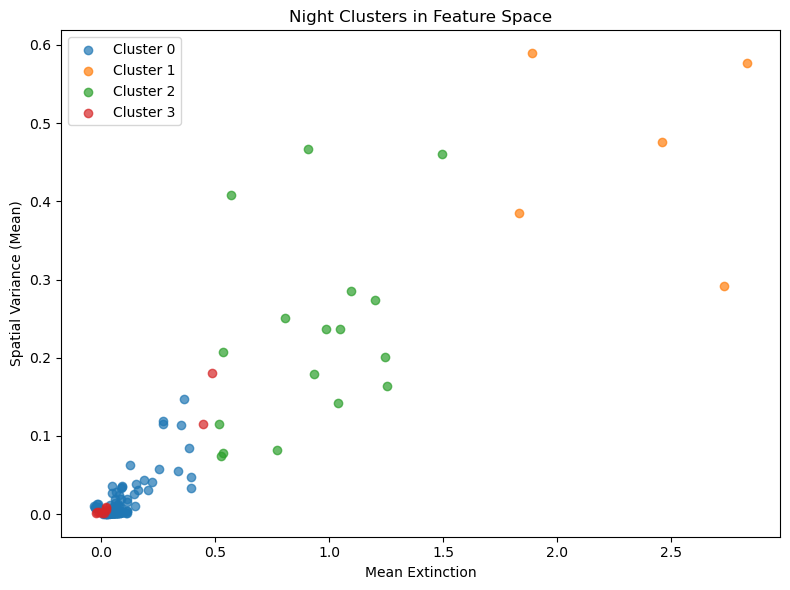

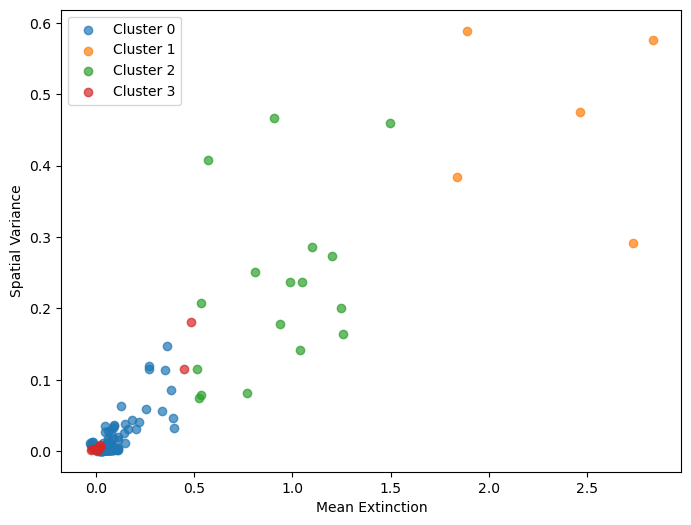

In [10]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("all_nights_classification.csv")

feature_cols = [
    "mean_extinction",
    "spatial_var_mean",
    "valid_frac_mean"
]

X = df[feature_cols].values

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df["cluster"] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

for cid in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cid]
    plt.scatter(
        subset["mean_extinction"],
        subset["spatial_var_mean"],
        label=f"Cluster {cid}",
        alpha=0.7
    )

plt.xlabel("Mean Extinction")
plt.ylabel("Spatial Variance")
plt.legend()
plt.show()